# Educational Knowledge Graph Project

## Building Structured Knowledge from Unstructured STEM Documents

**Group:** Group 7  
**Project Path:** Educational Knowledge Graph (Architect Path)  
**Instructor:** Jiaxin Du  

This project constructs a small educational knowledge graph from unstructured STEM text documents. Concepts are extracted using TF-IDF, refined through manual cleaning, and connected through sentence-level co-occurrence. The graph is modeled using Python and NetworkX.

In [59]:
import os

# Google Colab setup
if not os.path.exists("data"):
    !git clone https://github.com/Bless01/KDD_Group7.git
    %cd KDD_Group7

!python -m pip install -q networkx matplotlib scikit-learn pandas

## 1. Import Libraries

This section imports the required Python libraries for text processing, concept extraction, graph construction, visualization, and data summarization.

In [60]:
import os
os.environ["MPLCONFIGDIR"] = os.path.abspath("./mplconfig")

%matplotlib inline

import re
import itertools
from collections import Counter

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

## 2. Load Unstructured Educational Documents

The project uses raw `.txt` documents from the `data` folder as the input source. These documents represent unstructured STEM-related educational content.

In [61]:
data_folder = "data"
documents = []

if os.path.exists(data_folder) and os.path.isdir(data_folder):
    for file_name in sorted(os.listdir(data_folder)):
        if file_name.endswith(".txt"):
            with open(os.path.join(data_folder, file_name), "r", encoding="utf-8") as f:
                documents.append(f.read())
else:
    print(f"Warning: The folder '{data_folder}' does not exist or is not a directory. No documents loaded.")

print("Number of documents loaded:", len(documents))

if documents:
    for i, doc in enumerate(documents, 1):
        print(f"\nDocument {i} preview:")
        print(doc[:180])
else:
    print("No documents available for preview.")

Number of documents loaded: 5

Document 1 preview:
Computer Science

Computer science is the study of computation, information, and automation. It focuses on how computers process data, solve problems, and perform tasks efficiently

Document 2 preview:
Data Science

Data science is an interdisciplinary field that focuses on extracting useful knowledge and insights from data. It combines techniques from statistics, computer scienc

Document 3 preview:
Health Informatics

Health informatics is the use of computer science and information technology to improve healthcare systems. It focuses on managing medical data, improving commu

Document 4 preview:
Machine Learning

Machine learning is a branch of artificial intelligence that focuses on creating systems that can learn from data and improve their performance over time without 

Document 5 preview:
Cybersecurity

Cybersecurity (also known as computer security or IT security) is the practice of protecting computer systems, networks, and d

## 3. Text Cleaning and Sentence Segmentation

The raw text is converted to lowercase, special characters are removed, and the documents are split into sentences. This supports later concept extraction and relationship modeling.

In [62]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s.]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_docs = [clean_text(doc) for doc in documents]

print("Cleaned first document:")
print(cleaned_docs[0][:300] if cleaned_docs else "No documents available.")

Cleaned first document:
computer science computer science is the study of computation information and automation. it focuses on how computers process data solve problems and perform tasks efficiently. the field includes both theoretical concepts and practical applications such as designing software and building computer sy


In [63]:
sentences = []

for doc in cleaned_docs:
    parts = doc.split(".")
    for s in parts:
        s = s.strip()
        if s:
            sentences.append(s)

print("Number of sentences:", len(sentences))
print("\nFirst 5 sentences:")
for s in sentences[:5]:
    print("-", s)

Number of sentences: 76

First 5 sentences:
- computer science computer science is the study of computation information and automation
- it focuses on how computers process data solve problems and perform tasks efficiently
- the field includes both theoretical concepts and practical applications such as designing software and building computer systems
- key concepts in computer science computer science is built on several core ideas algorithms which are stepbystep procedures for solving problems data structures which organize and store data efficiently computation theory which studies what problems can be solved by computers programming which involves writing instructions for computers these concepts form the foundation for developing software and systems
- major areas of computer science computer science includes many specialized areas such as artificial intelligence which focuses on building systems that can learn and make decisions software engineering which deals with designing and

## 4. Concept Extraction with TF-IDF

Important two-word phrases are extracted using TF-IDF. These phrases act as candidate concepts for the knowledge graph.

In [64]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=30
)

X = vectorizer.fit_transform(cleaned_docs)
raw_concepts = list(vectorizer.get_feature_names_out())

print("Raw extracted concepts:")
for c in raw_concepts:
    print("-", c)

Raw extracted concepts:
- analyze data
- artificial intelligence
- computer science
- cybersecurity cybersecurity
- data science
- ethical concerns
- health informatics
- healthcare systems
- informatics health
- key concepts
- large datasets
- learning machine
- machine learning
- make predictions
- new data
- patient data
- process data
- role modern
- science computer
- science data
- sensitive information
- solve problems
- solving problems
- systems common
- systems data
- systems vulnerabilities
- technologies like
- trained using
- training data
- used realworld


## 5. Concept Refinement

Some extracted phrases are noisy or reversed. This step manually corrects concept names and removes weak or non-meaningful phrases so the final graph better reflects educational concepts.

In [65]:
fix_map = {
    "learning machine": "machine learning",
    "science data": "data science",
    "cybersecurity cybersecurity": "cybersecurity",
    "informatics health": "health informatics",
    "science computer": "computer science"
}

bad_terms = {
    "process data",
    "analyze data",
    "trained using",
    "technologies like",
    "systems common",
    "role modern",
    "new data",
    "science data",
    "learning machine",
    "cybersecurity cybersecurity",
    "make predictions",
    "used realworld",
    "solve problems",
    "solving problems",
    "sensitive information",
    "key concepts"
}

concepts = [fix_map.get(c, c) for c in raw_concepts]
concepts = [c for c in concepts if c not in bad_terms]
concepts = list(dict.fromkeys(concepts))

print("Cleaned concepts:")
for c in concepts:
    print("-", c)

Cleaned concepts:
- artificial intelligence
- computer science
- cybersecurity
- data science
- ethical concerns
- health informatics
- healthcare systems
- large datasets
- machine learning
- patient data
- systems data
- systems vulnerabilities
- training data


## 6. Relationship Construction

Relationships are inferred using sentence-level co-occurrence. If two concepts appear in the same sentence, they are treated as related. Edge weights represent how often the co-occurrence occurs.

In [66]:
edge_counter = Counter()

for sentence in sentences:
    present = []
    for concept in concepts:
        if concept in sentence:
            present.append(concept)

    present = list(set(present))
    for a, b in itertools.combinations(sorted(present), 2):
        edge_counter[(a, b)] += 1

print("Top relationships:")
for edge, weight in edge_counter.most_common(10):
    print(edge, "->", weight)

Top relationships:
('artificial intelligence', 'machine learning') -> 3
('health informatics', 'patient data') -> 3
('artificial intelligence', 'computer science') -> 2
('computer science', 'cybersecurity') -> 2
('computer science', 'data science') -> 2
('computer science', 'health informatics') -> 2
('data science', 'large datasets') -> 2
('health informatics', 'healthcare systems') -> 2
('artificial intelligence', 'cybersecurity') -> 1
('artificial intelligence', 'systems data') -> 1


## 7. Build the Knowledge Graph

Each concept becomes a node. Relationships are added as edges with a `related_to` label and a weight value.

In [67]:
G = nx.Graph()

for concept in concepts:
    G.add_node(concept)

for (a, b), weight in edge_counter.items():
    if weight >= 2:
        G.add_edge(a, b, weight=weight, relation="related_to")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 13
Edges: 8


## 8. Create a Clean Visualization for the Report

For the final report, isolated nodes are removed from the main visualization to improve readability. The resulting figure highlights the connected structure of the concept graph.

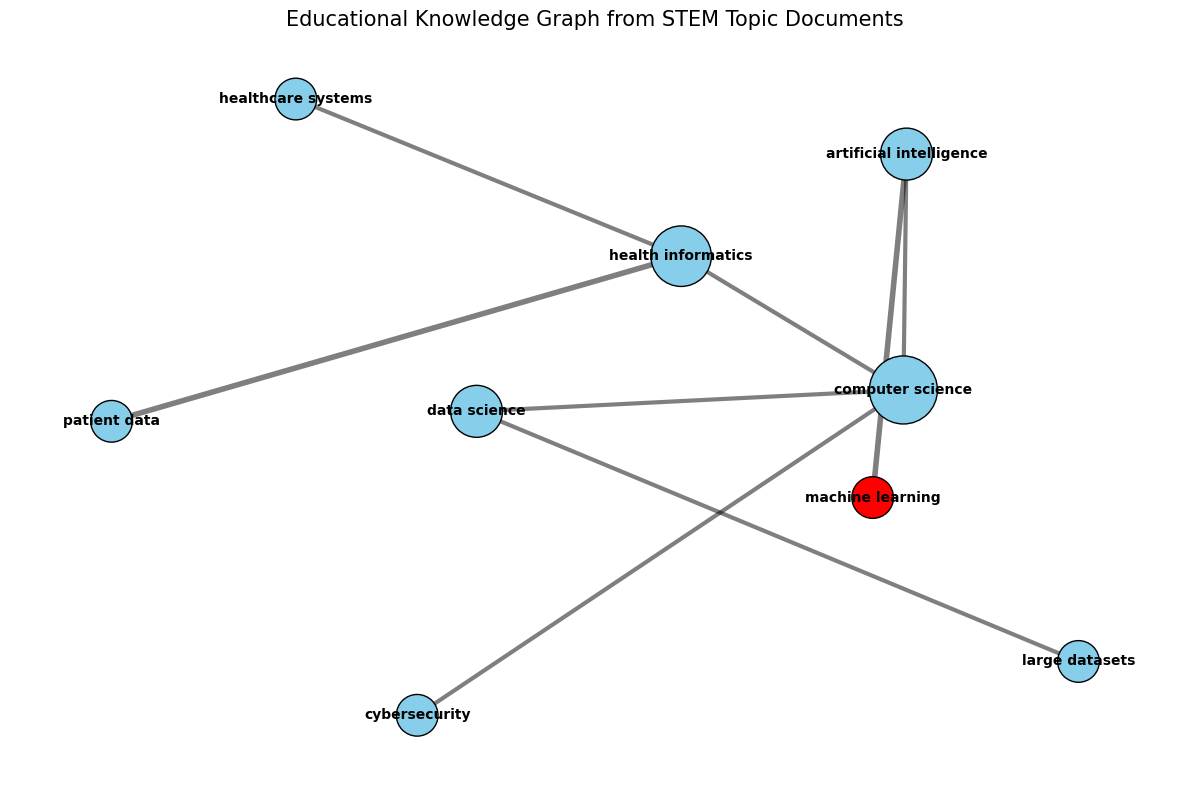

Saved: knowledge_graph_clean.png


In [68]:
G_plot = G.copy()
isolated_nodes = list(nx.isolates(G_plot))
G_plot.remove_nodes_from(isolated_nodes)

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G_plot, k=2.2, seed=42)
degree = dict(G_plot.degree())

node_sizes = [400 + degree[node] * 500 for node in G_plot.nodes()]
node_colors = ["red" if node == "machine learning" else "skyblue" for node in G_plot.nodes()]

nx.draw_networkx_nodes(
    G_plot,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black",
    linewidths=1
)

nx.draw_networkx_edges(
    G_plot,
    pos,
    width=[1 + G_plot[u][v]["weight"] for u, v in G_plot.edges()],
    alpha=0.5
)

nx.draw_networkx_labels(
    G_plot,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title("Educational Knowledge Graph from STEM Topic Documents", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.savefig("knowledge_graph_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: knowledge_graph_clean.png")

## 9. Concept Frequency Analysis

This chart shows which concepts appear most frequently across the document collection.

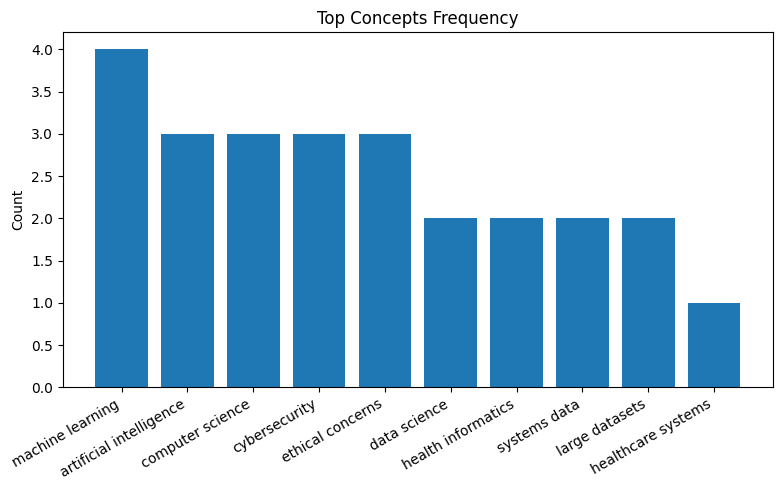

Saved: top_concepts_frequency.png


In [69]:
concept_counts = Counter()

for doc in cleaned_docs:
    for concept in concepts:
        if concept in doc:
            concept_counts[concept] += 1

top_concepts = concept_counts.most_common(10)

labels = [item[0] for item in top_concepts]
values = [item[1] for item in top_concepts]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.xticks(rotation=30, ha="right")
plt.title("Top Concepts Frequency")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("top_concepts_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: top_concepts_frequency.png")

## 10. Top Relationship Table

The following table summarizes the strongest concept-to-concept relationships identified in the document set.

In [70]:
top_edges_df = pd.DataFrame(
    [(a, b, w) for (a, b), w in edge_counter.most_common(10)],
    columns=["Concept 1", "Concept 2", "Weight"]
)

top_edges_df

,Concept 1,Concept 2,Weight
0,artificial intelligence,machine learning,3
1,health informatics,patient data,3
2,artificial intelligence,computer science,2
3,computer science,cybersecurity,2
4,computer science,data science,2
5,computer science,health informatics,2
6,data science,large datasets,2
7,health informatics,healthcare systems,2
8,artificial intelligence,cybersecurity,1
9,artificial intelligence,systems data,1


In [71]:
top_edges_df.to_csv("top_relationships.csv", index=False)
print("Saved: top_relationships.csv")

Saved: top_relationships.csv


## 11. Optional Concept Distribution Chart

This figure provides another view of concept proportions in the dataset. It is optional for the final report, but it may be useful in the notebook appendix.

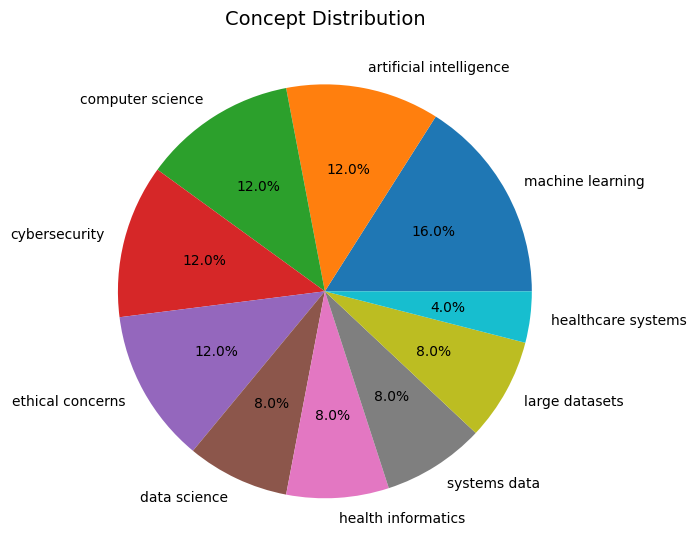

Saved: concept_distribution.png


In [72]:
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Concept Distribution", fontsize=14)
plt.tight_layout()
plt.savefig("concept_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: concept_distribution.png")

## 12. Interpretation of Results

The final graph highlights several central STEM concepts, particularly **computer science**, **health informatics**, **data science**, **artificial intelligence**, and **machine learning**. Larger node sizes indicate concepts with stronger connectivity in the graph, suggesting broader relevance across the document set.

The graph demonstrates that unstructured educational documents can be transformed into a structured representation of concepts and relationships. This supports the project objective of building a small educational knowledge graph using Python.

## 13. Limitations

This project has several limitations:

- Relationships were inferred using sentence-level co-occurrence rather than deep semantic parsing.
- Some concept refinement required manual cleaning.
- The dataset is relatively small and topic-limited.
- All edge labels were simplified as `related_to`.

Future work could use NLP-based entity recognition and more precise relation extraction methods such as prerequisite detection or ontology construction.

In [73]:
import os

output_files = [
    "knowledge_graph_clean.png",
    "top_concepts_frequency.png",
    "top_relationships.csv",
    "concept_distribution.png"
]

print("Generated files:")
for f in output_files:
    if os.path.exists(f):
        print("✓", f)
    else:
        print("✗", f)

Generated files:
✓ knowledge_graph_clean.png
✓ top_concepts_frequency.png
✓ top_relationships.csv
✓ concept_distribution.png
